# 01 EDA

In [1]:
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
if not os.path.exists("../data/raw/test_transaction.csv"):
    !{sys.executable} -m kaggle competitions download -c ieee-fraud-detection -p ../data/raw
    !unzip -o -q ../data/raw/ieee-fraud-detection.zip -d ../data/raw

transaction = pd.read_csv("../data/raw/train_transaction.csv")
identity = pd.read_csv("../data/raw/train_identity.csv")

print(transaction.shape, identity.shape)
print("fraud:", transaction["isFraud"].sum())

(590540, 394) (144233, 41)
fraud: 20663


In [3]:
transaction.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
identity.head()

,TransactionID,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987004,0.0,70787.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
1,2987008,-5.0,98945.0,NaN,NaN,0.0,-5.0,NaN,NaN,NaN,...,mobile safari 11.0,32.0,1334x750,match_status:1,T,F,F,T,mobile,iOS Device
2,2987010,-5.0,191631.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,Windows
3,2987011,-5.0,221832.0,NaN,NaN,0.0,-6.0,NaN,NaN,NaN,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,NaN
4,2987016,0.0,7460.0,0.0,0.0,1.0,0.0,NaN,NaN,0.0,...,chrome 62.0,24.0,1280x800,match_status:2,T,F,T,T,desktop,MacOS


In [5]:
groups = {
    "card": ["card1", "card2", "card3", "card4", "card5", "card6"],
    "addr": ["addr1", "addr2"],
    "dist": ["dist1", "dist2"],
    "email": ["P_emaildomain", "R_emaildomain"],
    "C": [f"C{i}" for i in range(1, 15)],
    "D": [f"D{i}" for i in range(1, 16)],
    "M": [f"M{i}" for i in range(1, 10)],
    "V": [f"V{i}" for i in range(1, 340)],
}

for name, cols in groups.items():
    print(name, len(cols), cols[:5])

card 6 ['card1', 'card2', 'card3', 'card4', 'card5']
addr 2 ['addr1', 'addr2']
dist 2 ['dist1', 'dist2']
email 2 ['P_emaildomain', 'R_emaildomain']
C 14 ['C1', 'C2', 'C3', 'C4', 'C5']
D 15 ['D1', 'D2', 'D3', 'D4', 'D5']
M 9 ['M1', 'M2', 'M3', 'M4', 'M5']
V 339 ['V1', 'V2', 'V3', 'V4', 'V5']


## Merge

In [6]:
has_identity = transaction["TransactionID"].isin(identity["TransactionID"]).rename("has_identity")
print(identity["TransactionID"].is_unique)

df = transaction.merge(identity, on="TransactionID", how="left")
print(df.shape)

del transaction, identity

True


(590540, 434)


## Target

isFraud
0    569877
1     20663
Name: count, dtype: int64
fraud rate: 0.03499000914417313


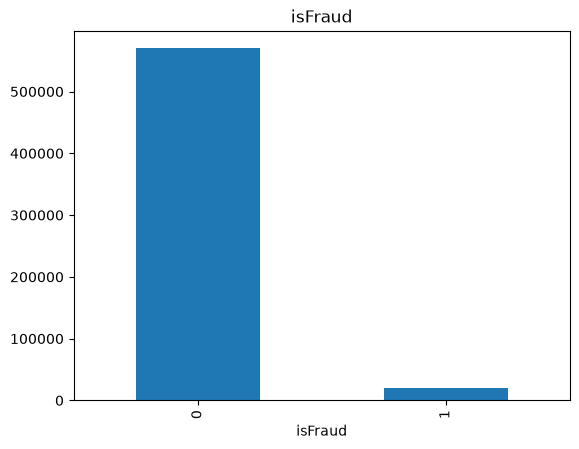

In [7]:
print(df["isFraud"].value_counts())
print("fraud rate:", df["isFraud"].mean())

df["isFraud"].value_counts().plot.bar(title="isFraud")
plt.show()

Only 3.5% of transactions are fraud, so accuracy is useless.

## Missing values

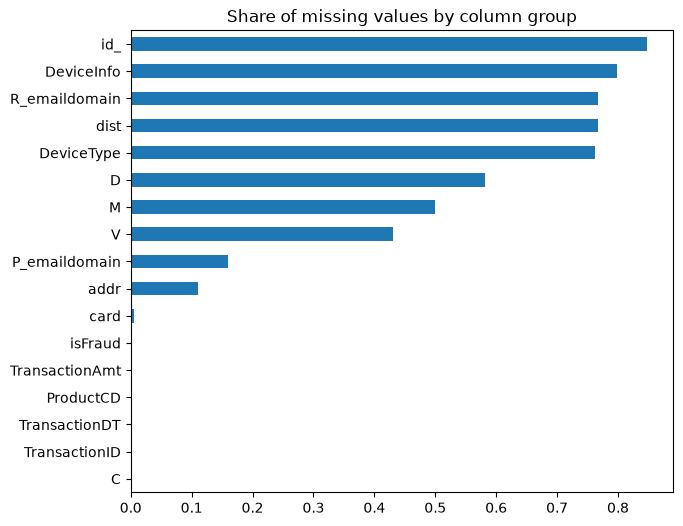

In [8]:
missing = df.isna().mean()
by_group = missing.groupby(missing.index.str.rstrip("0123456789")).mean()

by_group.sort_values().plot.barh(figsize=(7, 6), title="Share of missing values by column group")
plt.show()

In [9]:
print("share with identity:", has_identity.mean())
print(df.groupby(has_identity)["isFraud"].mean())

share with identity: 0.2442391709283029
has_identity
False    0.020939
True     0.078470
Name: isFraud, dtype: float64


Transactions with identity data are fraud almost 4 times more often.

In [10]:
rows = {}
for col in ["dist1", "D15", "M1", "V1", "R_emaildomain", "DeviceInfo"]:
    rows[col] = df.groupby(df[col].isna())["isFraud"].mean()

pd.DataFrame(rows).T.rename(columns={False: "present", True: "missing"})

,present,missing
dist1,0.019956,0.045158
D15,0.032681,0.047984
M1,0.019853,0.052826
V1,0.019617,0.052122
R_emaildomain,0.081775,0.020819
DeviceInfo,0.072531,0.025549


Missing values carry information about fraud.

## Time

In [11]:
day = (df["TransactionDT"] // 86400).rename("day")
hour = (df["TransactionDT"] // 3600 % 24).rename("hour")

print("days:", day.min(), "-", day.max())

days: 1 - 182


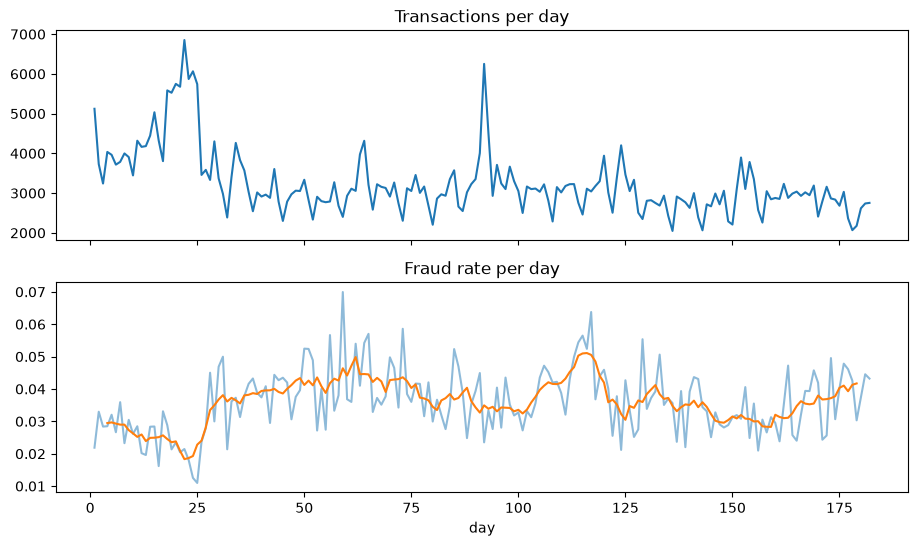

min: 0.0109717868338558
max: 0.06994171523730225


In [12]:
daily = df.groupby(day)["isFraud"].agg(["size", "mean"])

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
axes[0].plot(daily.index, daily["size"])
axes[0].set_title("Transactions per day")
axes[1].plot(daily.index, daily["mean"], alpha=0.5)
axes[1].plot(daily.index, daily["mean"].rolling(7, center=True).mean())
axes[1].set_title("Fraud rate per day")
axes[1].set_xlabel("day")
plt.show()

print("min:", daily["mean"].min())
print("max:", daily["mean"].max())

In [13]:
df.groupby(day <= 27)["isFraud"].agg(["size", "mean"])

,size,mean
day,,
False,467206,0.037883
True,123334,0.024032


The fraud rate changes from 1% to 7% per day, so validation has to follow time.

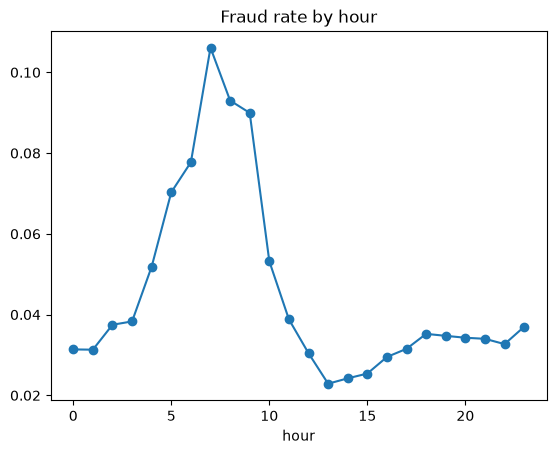

min: 0.02288949052424317
max: 0.10610151187904968


In [14]:
hourly = df.groupby(hour)["isFraud"].mean()
hourly.plot(marker="o", title="Fraud rate by hour")
plt.show()

print("min:", hourly.min())
print("max:", hourly.max())

Fraud also depends on the hour.

## TransactionAmt

In [15]:
print(df["TransactionAmt"].describe())
print(df.groupby("isFraud")["TransactionAmt"].median())

count    590540.000000
mean        135.027176
std         239.162522
min           0.251000
25%          43.321000
50%          68.769000
75%         125.000000
max       31937.391000
Name: TransactionAmt, dtype: float64
isFraud
0    68.5
1    75.0
Name: TransactionAmt, dtype: float64


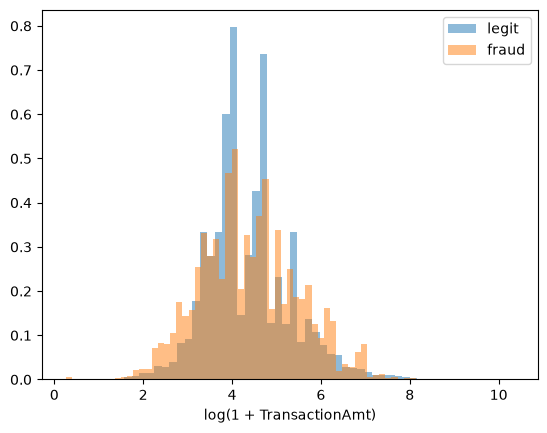

In [16]:
log_amt = np.log1p(df["TransactionAmt"])

plt.hist(log_amt[df["isFraud"] == 0], bins=60, density=True, alpha=0.5, label="legit")
plt.hist(log_amt[df["isFraud"] == 1], bins=60, density=True, alpha=0.5, label="fraud")
plt.xlabel("log(1 + TransactionAmt)")
plt.legend()
plt.show()

In [17]:
has_cents = (df["TransactionAmt"] % 1 != 0).rename("has_cents")
df.groupby(has_cents)["isFraud"].mean()

has_cents
False    0.035677
True     0.034256
Name: isFraud, dtype: float64

The amount alone is a weak feature.

## Categorical features

In [18]:
product = df.groupby("ProductCD")["isFraud"].agg(["size", "sum", "mean"])
product["share_of_fraud"] = product["sum"] / product["sum"].sum()
product

,size,sum,mean,share_of_fraud
ProductCD,,,,
C,68519,8008,0.116873,0.387553
H,33024,1574,0.047662,0.076175
R,37699,1426,0.037826,0.069012
S,11628,686,0.058996,0.033199
W,439670,8969,0.020399,0.434061


Product `C` is 12% of transactions but almost 40% of all fraud.

In [19]:
for col in ["card4", "card6", "DeviceType"]:
    print(df.groupby(col)["isFraud"].agg(["size", "mean"]))
    print()

                    size      mean
card4                             
american express    8328  0.028698
discover            6651  0.077282
mastercard        189217  0.034331
visa              384767  0.034756

                   size      mean
card6                            
charge card          15  0.000000
credit           148986  0.066785
debit            439938  0.024263
debit or credit      30  0.000000

             size      mean
DeviceType                 
desktop     85165  0.065215
mobile      55645  0.101662



In [20]:
email = df.groupby("P_emaildomain")["isFraud"].agg(["size", "mean"])
email = email[email["size"] >= 1000].sort_values("mean", ascending=False)

print(email.head())
print(email.tail())

                 size      mean
P_emaildomain                  
outlook.com      5096  0.094584
hotmail.com     45250  0.052950
gmail.com      228355  0.043542
icloud.com       6267  0.031434
comcast.net      7888  0.031187
               size      mean
P_emaildomain                
optonline.net  1011  0.016815
yahoo.com.mx   1543  0.010369
verizon.net    2705  0.008133
att.net        4033  0.007439
sbcglobal.net  2970  0.004040


Credit cards, mobile devices and some email domains have much more fraud.

In [21]:
cat_cols = ["ProductCD", "card1", "card2", "card3", "card4", "card5", "card6",
            "addr1", "addr2", "P_emaildomain", "R_emaildomain", "DeviceType", "DeviceInfo"]

df[cat_cols].nunique().sort_values(ascending=False)

card1            13553
DeviceInfo        1786
card2              500
addr1              332
card5              119
card3              114
addr2               74
R_emaildomain       60
P_emaildomain       59
ProductCD            5
card4                4
card6                4
DeviceType           2
dtype: int64

`card1` has more than 13 thousand values, so the neural net uses embeddings.

## Anonymous blocks

In [22]:
v_missing = df[groups["V"]].isna().sum()

print("different missing counts:", v_missing.nunique())
print(v_missing.value_counts().head())

different missing counts: 15
460110    46
314       43
12        32
450909    31
76073     23
Name: count, dtype: int64


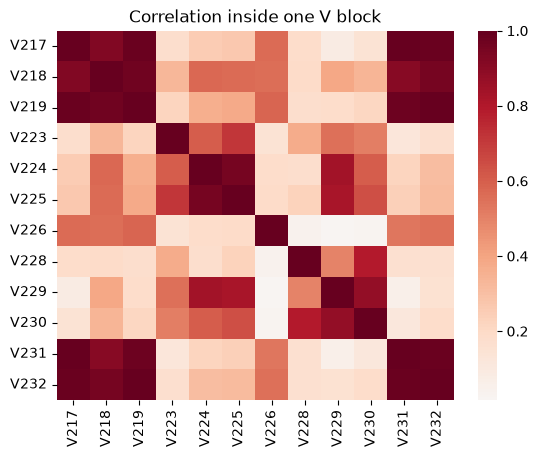

In [23]:
biggest = v_missing.value_counts().index[0]
block = v_missing[v_missing == biggest].index[:12]

sns.heatmap(df[block].corr(), cmap="RdBu_r", center=0)
plt.title("Correlation inside one V block")
plt.show()

The `V` columns come in groups of strongly correlated columns.

In [24]:
df[groups["D"]].corrwith(df["TransactionDT"]).sort_values(key=abs, ascending=False)

D11    0.101266
D14    0.097509
D6     0.084581
D1     0.074031
D15    0.072791
D7    -0.070221
D8    -0.068752
D4     0.059797
D10    0.058409
D12    0.053108
D2     0.027109
D13    0.024405
D9    -0.013735
D3    -0.007200
D5     0.001767
dtype: float64

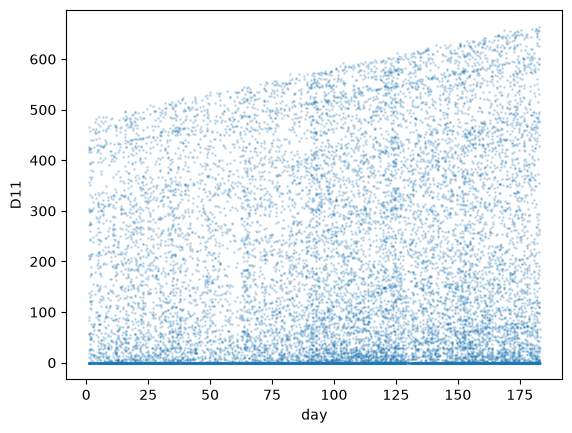

In [25]:
sample = df[["TransactionDT", "D11"]].dropna().sample(20000, random_state=42)

plt.scatter(sample["TransactionDT"] / 86400, sample["D11"], s=1, alpha=0.2)
plt.xlabel("day")
plt.ylabel("D11")
plt.show()

In [26]:
early = df.loc[day <= 45, "D11"].dropna()
late = df.loc[day >= 135, "D11"].dropna()

print("median:", early.median(), late.median())
print("max:", early.max(), late.max())
print("share of zeros:", (early == 0).mean(), (late == 0).mean())

median: 24.0 63.0
max: 532.0 670.0
share of zeros: 0.4180402314316469 0.31129444817175445


`D11` drifts over time, even though its correlation with time is small.

## Test set

In [27]:
test = pd.read_csv("../data/raw/test_transaction.csv", usecols=["TransactionID", "TransactionDT", "TransactionAmt", "ProductCD", "card1"])
test_identity = pd.read_csv("../data/raw/test_identity.csv")

print(test.shape, test_identity.shape)
print(test_identity.columns[:4].tolist())

test_day = test["TransactionDT"] // 86400
print("train days:", day.min(), "-", day.max())
print("test days:", test_day.min(), "-", test_day.max())
print("share with identity:", test["TransactionID"].isin(test_identity["TransactionID"]).mean())

(506691, 5) (141907, 41)
['TransactionID', 'id-01', 'id-02', 'id-03']
train days: 1 - 182
test days: 213 - 395
share with identity: 0.28006615471756946


In [28]:
pd.DataFrame({
    "train": df["ProductCD"].value_counts(normalize=True),
    "test": test["ProductCD"].value_counts(normalize=True),
}).round(3)

,train,test
ProductCD,,
W,0.745,0.712
C,0.116,0.137
R,0.064,0.070
H,0.056,0.058
S,0.020,0.023


In [29]:
print("test card1 values seen in train:", test["card1"].isin(df["card1"]).mean())
print("median amount, train:", df["TransactionAmt"].median(), "test:", test["TransactionAmt"].median())

test card1 values seen in train: 0.9815272029698574
median amount, train: 68.769 test: 67.95


The test starts a month after train, and 98% of its `card1` values are already in train.

## Summary

- Only 3.5% of transactions are fraud, so accuracy is useless.
- The fraud rate changes over time, so validation has to follow time.
- Missing values and identity data are related to fraud.
- Product `C` has a big part of the fraud.
- Some features drift over time.
- The test comes a month after train.